In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


In [1]:
# 7. On/Off Net Rating 대안 시각화: Dumbbell Plot & Slope Chart
# CSV 경로: 2024-25 시즌 on/off rate 파일 경로로 변경
csv_path = r"C:/Users/USER/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/7번 시각화/gsw_2024_25_onoffrate.csv"

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from nba_api.stats.endpoints.teamplayeronoffsummary import TeamPlayerOnOffSummary

# ──────────────────────────────────────────────────────────────────────────
# 1) 2024-25 시즌 GSW On/Off 데이터 가져오기 (MIN + NET_RATING 포함)
# ──────────────────────────────────────────────────────────────────────────
call = TeamPlayerOnOffSummary(
    team_id='1610612744',
    season='2024-25',
    season_type_all_star='Regular Season',
    measure_type_detailed_defense='Base',
    per_mode_detailed='PerGame',
    league_id_nullable='00'
)
# 반환되는 세 개 DataFrame 중 Off, On 추출
_, off_df, on_df = call.get_data_frames()

# MIN 과 NET_RATING만 뽑아서 컬럼명 맞추기
off_net = (
    off_df[['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'Min_Off','NET_RATING':'Net_Off'})
)
on_net = (
    on_df [['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'Min_On','NET_RATING':'Net_On'})
)

# 병합
df = pd.merge(on_net, off_net, on='PLAYER_NAME')

# ──────────────────────────────────────────────────────────────────────────
# 2) 주전 필터링 (예: 200분 이상)
# ──────────────────────────────────────────────────────────────────────────
starter_thresh = 200
starters = df[(df['Min_On']  >= starter_thresh) &
              (df['Min_Off'] >= starter_thresh)].copy()

# 정렬: On-Off 차이 큰 순
starters['Diff'] = starters['Net_On'] - starters['Net_Off']
starters = starters.sort_values('Diff', ascending=False).reset_index(drop=True)

In [55]:
starters

,PLAYER_NAME,Min_On,Net_On,Min_Off,Net_Off,Diff
0,"Schröder, Dennis",668.0,0.0,628.0,-9.6,9.6
1,"Jackson-Davis, Trayce",2979.0,5.3,967.0,-3.5,8.8
2,"Anderson, Kyle",1912.0,1.1,541.0,-6.8,7.9
3,"Spencer, Pat",3696.0,3.6,250.0,-2.8,6.4
4,"Wiggins, Andrew",1157.0,1.6,1296.0,-1.8,3.4
5,"Kuminga, Jonathan",2802.0,3.9,1144.0,1.0,2.9
6,"Butler III, Jimmy",513.0,10.4,980.0,8.8,1.6
7,"Hield, Buddy",2083.0,3.6,1863.0,2.2,1.4
8,"Waters III, Lindy",1798.0,0.0,655.0,-1.1,1.1
9,"Post, Quinten",3260.0,3.1,686.0,2.4,0.7


C:\Users\USER\AppData\Local\Temp\ipykernel_16340\2342545611.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.94])


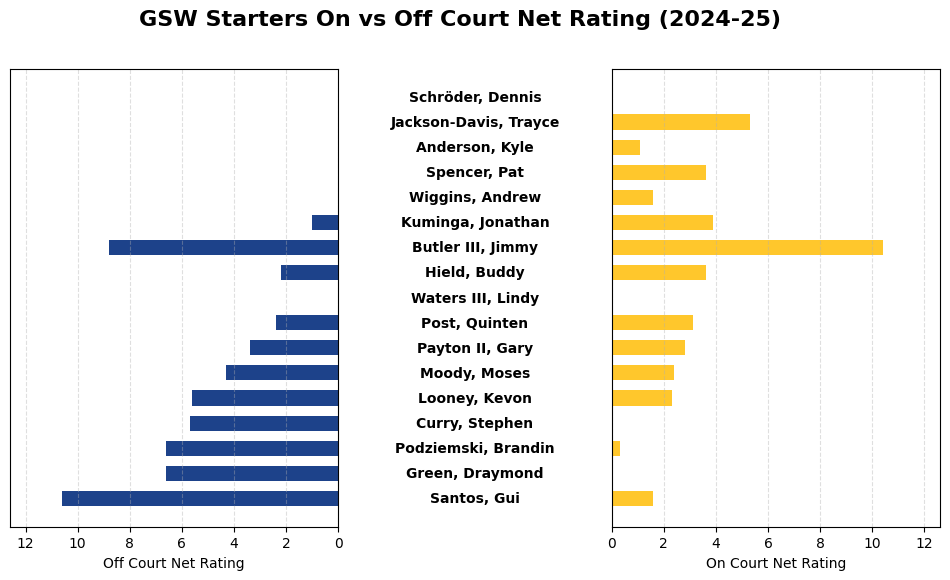

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from nba_api.stats.endpoints.teamplayeronoffsummary import TeamPlayerOnOffSummary
from matplotlib.ticker import FuncFormatter

# 1) 데이터 호출 & 전처리 ─────────────────────────────────────────────────
call = TeamPlayerOnOffSummary(
    team_id='1610612744', season='2024-25',
    season_type_all_star='Regular Season',
    measure_type_detailed_defense='Base',
    per_mode_detailed='PerGame',
    league_id_nullable='00'
)
_, off_df, on_df = call.get_data_frames()
off = (
    off_df[['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'MIN_Off','NET_RATING':'Off'})
)
on  = (
    on_df [['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'MIN_On','NET_RATING':'On'})
)
df = pd.merge(on, off, on='PLAYER_NAME')

# 2) 주전(200분 이상) 필터 & 정렬
starters = df[(df.MIN_On>=200)&(df.MIN_Off>=200)].copy()
starters['Diff'] = starters.On - starters.Off
starters = starters.sort_values('Diff', ascending=False).reset_index(drop=True)

players  = starters.PLAYER_NAME.tolist()
off_vals = starters.Off.values
on_vals  = starters.On.values
n        = len(starters)
inds     = np.arange(n)

# 3) 스타일 세팅 ─────────────────────────────────────────────────────────
gsw_blue, gsw_yellow = '#1D428A','#FFC72C'
mpl.rcParams.update({
    'axes.facecolor':'white',
    'figure.facecolor':'white',
    'font.size':11,
})
plt.style.use('default')

# x축 한계
lim = max(off_vals.max(), on_vals.max()) + 2

# 4) Figure & GridSpec ────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, n*0.35))
gs  = fig.add_gridspec(1, 3, width_ratios=[1,0.5,1], wspace=0.2)
axL = fig.add_subplot(gs[0,0])
axC = fig.add_subplot(gs[0,1], sharey=axL)
axR = fig.add_subplot(gs[0,2], sharey=axL)
bar_h = 0.6

# 5) 왼쪽: Off Court ─────────────────────────────────────────────────────
axL.barh(inds, off_vals, height=bar_h, color=gsw_blue)
axL.invert_xaxis()
axL.set(xlim=(lim, 0), xlabel='Off Court Net Rating')
axL.xaxis.set_major_formatter(FuncFormatter(lambda x,pos: f"{abs(x):.0f}"))
axL.grid(axis='x', linestyle='--', alpha=0.4)
# (숫자 레이블 제거)
# for y, v in zip(inds, off_vals):
#     axL.text(-v, y, f"{v:.1f}", ha='right', va='center',
#              color=gsw_blue, fontsize=9, clip_on=False)

# 6) 중앙: 선수 이름 ──────────────────────────────────────────────────────
axC.set(xticks=[], yticks=[])
for sp in axC.spines.values(): sp.set_visible(False)
for y, name in zip(inds, players):
    axC.text(0.5, y, name, ha='center', va='center',
             fontsize=10, fontweight='bold', clip_on=False)

# 7) 오른쪽: On Court ────────────────────────────────────────────────────
axR.barh(inds, on_vals, height=bar_h, color=gsw_yellow)
axR.set(xlim=(0, lim), xlabel='On Court Net Rating')
axR.grid(axis='x', linestyle='--', alpha=0.4)
# (숫자 레이블 제거)
# for y, v in zip(inds, on_vals):
#     axR.text(v+0.3, y, f"{v:.1f}", ha='left', va='center',
#              color='black', fontsize=9, clip_on=False)

# 8) Y축 완전 제거 & 순서 고정 ─────────────────────────────────────────────
for ax in (axL, axC, axR):
    ax.set(yticks=[])
    ax.invert_yaxis()

# 9) 제목 & 레이아웃 ─────────────────────────────────────────────────────
fig.suptitle('GSW Starters On vs Off Court Net Rating (2024-25)',
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.94])
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_16340\3159917784.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.94])


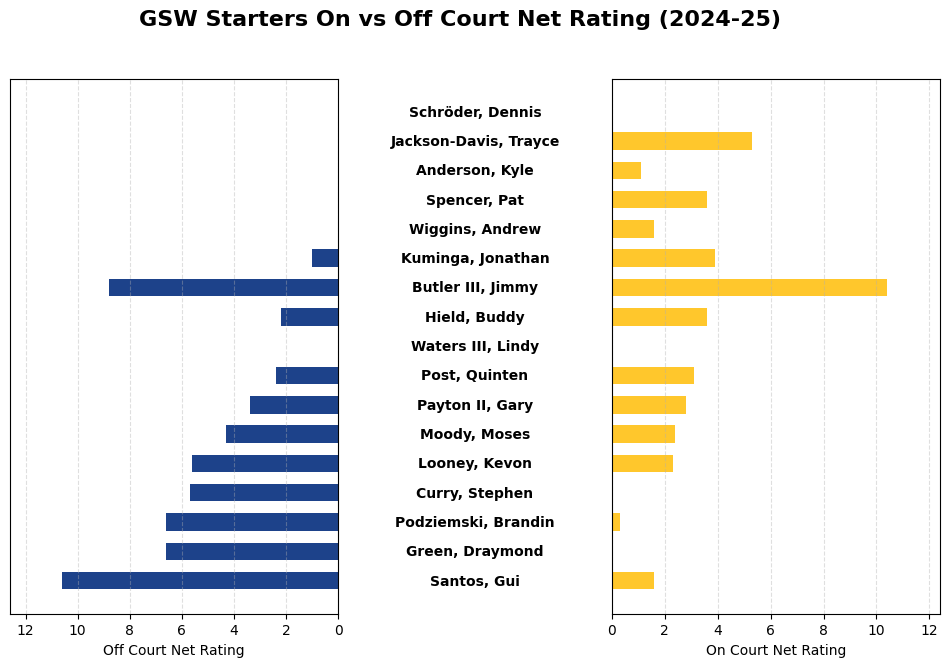

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from nba_api.stats.endpoints.teamplayeronoffsummary import TeamPlayerOnOffSummary
from matplotlib.ticker import FuncFormatter

# 1) 데이터 호출 & 전처리
call = TeamPlayerOnOffSummary(
    team_id='1610612744',
    season='2024-25',
    season_type_all_star='Regular Season',
    measure_type_detailed_defense='Base',
    per_mode_detailed='PerGame',
    league_id_nullable='00'
)
_, off_df, on_df = call.get_data_frames()

off = (
    off_df[['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'MIN_Off','NET_RATING':'Off'})
)
on = (
    on_df[['VS_PLAYER_NAME','MIN','NET_RATING']]
    .rename(columns={'VS_PLAYER_NAME':'PLAYER_NAME','MIN':'MIN_On','NET_RATING':'On'})
)

df = pd.merge(on, off, on='PLAYER_NAME')

# 2) 주전(200분 이상) 필터 & 정렬
starters = df[(df.MIN_On >= 200) & (df.MIN_Off >= 200)].copy()
starters['Diff'] = starters.On - starters.Off
starters = starters.sort_values('Diff', ascending=False).reset_index(drop=True)

players  = starters.PLAYER_NAME.tolist()
off_vals = -starters.Off.values    # Off Court 값을 음수로 변환
on_vals  =  starters.On.values
n        = len(starters)
inds     = np.arange(n)

# 3) 스타일 세팅
gsw_blue, gsw_yellow = '#1D428A', '#FFC72C'
mpl.rcParams.update({
    'axes.facecolor':'white',
    'figure.facecolor':'white',
    'font.size':11,
})
plt.style.use('default')

# 4) x축 한계 설정 (음수 & 양수 최대값에 여유 추가)
lim_neg = off_vals.min() - 2
lim_pos = on_vals.max()  + 2

# 5) Figure & GridSpec
fig = plt.figure(figsize=(12, n*0.35 + 1))
gs  = fig.add_gridspec(1, 3, width_ratios=[1,0.5,1], wspace=0.2)
axL = fig.add_subplot(gs[0,0])
axC = fig.add_subplot(gs[0,1], sharey=axL)
axR = fig.add_subplot(gs[0,2], sharey=axL)
bar_h = 0.6

# 6) 왼쪽: Off Court Net Rating
axL.barh(inds, off_vals, height=bar_h, color=gsw_blue)
axL.set(xlim=(lim_neg, 0), xlabel='Off Court Net Rating')
axL.xaxis.set_major_formatter(FuncFormatter(lambda x,pos: f"{abs(int(x))}"))
axL.grid(axis='x', linestyle='--', alpha=0.4)

# 7) 중앙: 선수 이름
axC.set(xticks=[], yticks=[])
for sp in axC.spines.values():
    sp.set_visible(False)
for y, name in zip(inds, players):
    axC.text(0.5, y, name,
             ha='center', va='center',
             fontsize=10, fontweight='bold',
             transform=axC.get_yaxis_transform())

# 8) 오른쪽: On Court Net Rating
axR.barh(inds, on_vals, height=bar_h, color=gsw_yellow)
axR.set(xlim=(0, lim_pos), xlabel='On Court Net Rating')
axR.grid(axis='x', linestyle='--', alpha=0.4)

# 9) y축 완전 제거 & 순서 고정
for ax in (axL, axC, axR):
    ax.set(yticks=[])
    ax.invert_yaxis()

# 10) 제목 & 레이아웃 조정
fig.suptitle('GSW Starters On vs Off Court Net Rating (2024-25)',
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.94])
plt.show()
